# Physics-Informed Neural Network for Grid Inertia Estimation

## Physics

The **stochastic swing equation** governs frequency dynamics:

$$M \frac{df}{dt} + D(f - f_0) = \xi(t)$$

where $\xi(t)$ is an unknown stochastic power imbalance process that we never observe directly.

## How M and D are identified

Define the residual $R(t) = M \frac{df}{dt} + D(f - f_0)$.

For the **correct** $(M, D)$: $R(t) = \xi(t)$ — white noise, zero autocorrelation at all lags.

For **wrong** $(M, D)$: $R(t)$ retains structure:
- $M$ too large → $R$ oscillates → positive autocorrelation at short lags
- $M$ too small → $D$ dominates → $R$ mean-reverts too fast → autocorrelation structure
- $D$ too large → $R$ over-damps → negative autocorrelation
- $D$ too small → $R$ has long memory → positive autocorrelation at long lags

Only the correct pair whitens $R$. The physics loss enforces this.

## Why the PINN is non-trivial

1. **Smooth $df/dt$**: the network learns $\hat{f}(t)$ from noisy 1-second data.
   Autograd gives a clean $d\hat{f}/dt$ — not noisy finite differences.
   Traditional finite differences on 1-second data are noise-dominated.

2. **No ΔP required**: M and D are identified from frequency statistics alone.
   The traditional table method requires full generation dispatch data
   and misses all load-side inertia.

3. **Continuous real-time estimates**: sliding window gives $M(t)$ and $D(t)$
   at 30-minute resolution. Table method gives one number per 15-minute interval
   from stale, incomplete data.

## 0. Setup

In [1]:
import sys, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (16, 5)

sys.path.append(str(Path('..').resolve()))
from models.pinn import InertiaPINN, prepare_window, make_colloc, F0, AUTOCORR_LAGS
from models.losses import PINNLoss, autocorr

GLOBAL_SEED = 42
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed(GLOBAL_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Config

In [32]:
DATA_DIR  = Path('../data/processed')
CKPT_DIR  = Path('../checkpoints/pinn'); CKPT_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_S  = 3600
STEP_S    = 1800
YEAR      = 2018

HIDDEN_DIM   = 64
N_LAYERS     = 5
N_MEMBERS    = 5
N_COLLOC     = 1000
M_INIT       = 5.0
D_INIT       = 2.0

EPOCHS       = 10000
LR           = 1e-3
ALPHA        = 1.0
BETA_MAX     = 16.0
GAMMA_MAX    = 0.1
GAMMA_MIN    = 0.001
M_PRIOR      = 2.8 # Reset later
M_STD        = 3.0
WARMUP_DATA  = 200
WARMUP_PHYS  = 800

H_CONSTANTS = {
    'P_thermal':       5.0,
    'P_solar':         0.0,
    'P_wind_onshore':  0.0,
    'P_wind_offshore': 0.0,
    'P_hydro':         3.0,
}
print('Config loaded.')

Config loaded.


## 2. Load data

In [3]:
freq_path = Path('../data/raw') / f'de_frequency_1s_{YEAR}.csv'
df_freq = pd.read_csv(freq_path, index_col='utc_timestamp', parse_dates=True)
if df_freq.index.tz is None:
    df_freq.index = df_freq.index.tz_localize('UTC')
df_freq = df_freq.sort_index()[~df_freq.index.duplicated()]

df_15 = pd.read_csv(DATA_DIR / 'de_inertia_15min.csv',
                    index_col='utc_timestamp', parse_dates=True)
if df_15.index.tz is None:
    df_15.index = df_15.index.tz_localize('UTC')

print(f'Frequency : {len(df_freq):,} seconds')
print(f'15-min    : {len(df_15):,} rows')

Frequency : 31,536,000 seconds
15-min    : 201,604 rows


## 3. Traditional baseline

The table method weights generation types by known inertia constants.
It systematically misses load-side inertia and requires generation dispatch data.

Table H_sys : mean=2.843  std=0.730 MWs/MVA
Assigns 0 to wind/solar, ignores all load-side inertia


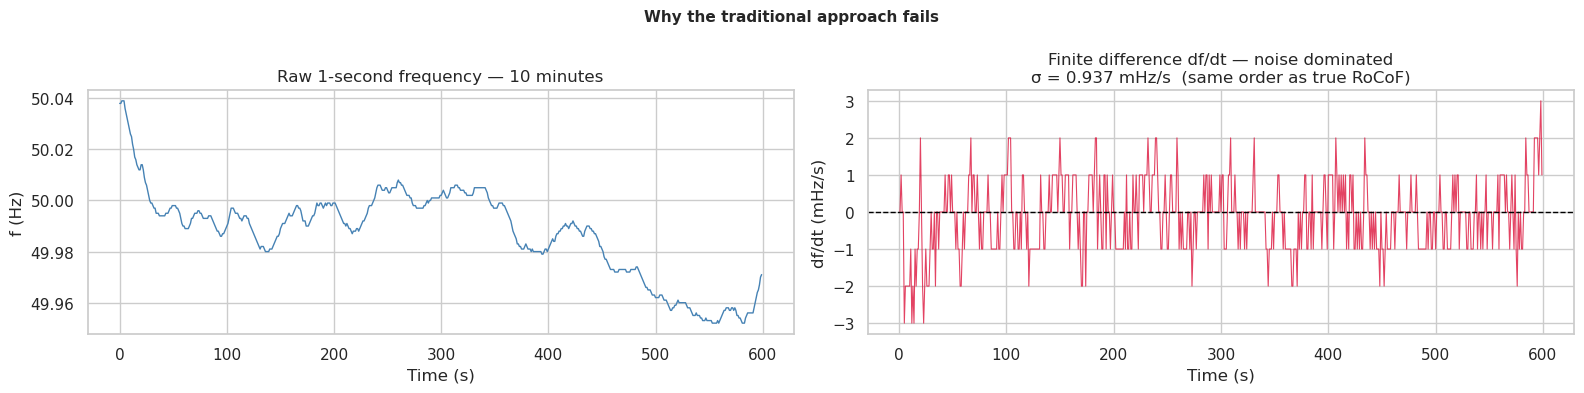

In [4]:
def get_traditional_inertia(df_15min):
    weighted = sum(
        df_15min[col].fillna(0) * H
        for col, H in H_CONSTANTS.items()
        if col in df_15min.columns
    )
    P_total = df_15min['P_total'].replace(0, np.nan)
    return (weighted / P_total).rename('H_traditional')

H_trad = get_traditional_inertia(df_15)
M_table_mean = float(H_trad.mean())

M_PRIOR = M_table_mean

print(f'Table H_sys : mean={M_table_mean:.3f}  std={H_trad.std():.3f} MWs/MVA')
print(f'Assigns 0 to wind/solar, ignores all load-side inertia')

# Show the noise problem
demo  = df_freq['f_hz'].iloc[:600]
rocof = demo.diff()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(np.arange(len(demo)), demo.values, color='steelblue', lw=1)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('f (Hz)')
axes[0].set_title('Raw 1-second frequency — 10 minutes')

axes[1].plot(np.arange(len(rocof)), rocof.values*1000, color='crimson', lw=0.8, alpha=0.8)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('df/dt (mHz/s)')
axes[1].set_title(
    f'Finite difference df/dt — noise dominated\n'
    f'σ = {rocof.std()*1000:.3f} mHz/s  (same order as true RoCoF)'
)
plt.suptitle('Why the traditional approach fails', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Prepare window

Only f(t) is needed. No power data required.
StandardScaler on f — network works on O(1) inputs.

In [5]:
START_IDX = 12 * 3600
window    = prepare_window(df_freq, df_15, START_IDX, WINDOW_S)

print(f'Window    : {window["index"][0]}  →  {window["index"][-1]}')
print(f'f range   : [{window["f_raw_hz"].min():.5f}, {window["f_raw_hz"].max():.5f}] Hz')
print(f'f_s range : [{window["f_s"].min():.3f}, {window["f_s"].max():.3f}]  (scaled, O(1))')
print(f'f_dev     : [{window["f_dev"].min():.5f}, {window["f_dev"].max():.5f}] Hz')
print(f'\nNo power data needed — M and D identified from frequency statistics alone.')

Window    : 2018-01-01 12:00:00+00:00  →  2018-01-01 12:59:59+00:00
f range   : [49.96900, 50.03100] Hz
f_s range : [-2.819, 2.453]  (scaled, O(1))
f_dev     : [-0.03100, 0.03100] Hz

No power data needed — M and D identified from frequency statistics alone.


## 5. Train one member

Watch the table:
- **L_white** is the sum of squared autocorrelations of R — should decrease as M and D converge
- **M** and **D** should move from their initial values
- **beta** ramps up — whiteness loss takes over from data loss
- **gamma** decays — prior goes silent

In [33]:
set_seed(GLOBAL_SEED)
model = InertiaPINN(
    scalers=window['scalers'],
    hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS,
    t_scale=window['t_scale'],
    M_init=M_INIT, D_init=D_INIT,
).to(DEVICE)

criterion = PINNLoss(
    alpha=ALPHA, beta_max=BETA_MAX,
    gamma_max=GAMMA_MAX, gamma_min=GAMMA_MIN,
    M_prior=M_PRIOR, M_std=M_STD,
    lags=AUTOCORR_LAGS,
    warmup_data=WARMUP_DATA, warmup_phys=WARMUP_PHYS,
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS)

t_norm  = window['t_norm'].to(DEVICE).requires_grad_(True)
f_s     = window['f_s'].to(DEVICE)
t_c, fdev_c = make_colloc(window, N_COLLOC, DEVICE)

log = []
print(f'{"Ep":>5}  {"L_tot":>9}  {"L_data":>9}  {"L_white":>9}  '
      f'{"L_prior":>9}  {"beta":>5}  {"gamma":>6}  {"M [MWs/MVA]":>12}  {"D [MW/Hz]":>10}')
print('─' * 95)

for epoch in range(1, EPOCHS+1):
    model.train()
    criterion.schedule(epoch)

    f_s_pred = model._forward_scaled(t_norm)
    R        = model.residual(t_c, fdev_c)
    loss, bd = criterion(f_s_pred, f_s, R,
                         nn.functional.softplus(model._M_raw))

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    log.append(dict(epoch=epoch, M=model.M, D=model.D, **bd))

    if epoch % 500 == 0 or epoch == 1:
        print(f'{epoch:5d}  {bd["loss_total"]:9.3e}  {bd["loss_data"]:9.3e}  '
              f'{bd["loss_white"]:9.3e}  {bd["loss_prior"]:9.3e}  '
              f'{bd["beta"]:5.1f}  {bd["gamma"]:6.3f}  '
              f'{model.M:12.4f}  {model.D:10.4f}')

log_df = pd.DataFrame(log)
print('─' * 95)
print(f'Final  M = {model.M:.4f} MWs/MVA')
print(f'Final  D = {model.D:.4f} MW/Hz')
print(f'Table  M = {M_table_mean:.4f} MWs/MVA  (misses load-side inertia)')

   Ep      L_tot     L_data    L_white    L_prior   beta   gamma   M [MWs/MVA]   D [MW/Hz]
───────────────────────────────────────────────────────────────────────────────────────────────
    1  1.054e+00  9.999e-01  5.228e-01  5.378e-01    0.0   0.100        4.9990      2.0000
  500  4.616e+00  4.200e-01  5.228e-01  3.661e-01    8.0   0.038        4.6146      1.9188
 1000  8.706e+00  3.716e-01  5.208e-01  3.408e-01   16.0   0.001        4.5516      0.9717
 1500  8.185e+00  4.682e-01  4.822e-01  4.280e-01   16.0   0.001        4.7634      0.4339
 2000  2.235e+00  1.002e+00  7.704e-02  5.781e-01   16.0   0.001        5.0812      0.2817
 2500  1.187e+00  7.362e-01  2.813e-02  5.947e-01   16.0   0.001        5.1136      0.2713
 3000  1.416e+00  8.984e-01  3.234e-02  6.045e-01   16.0   0.001        5.1326      0.2654
 3500  6.402e-01  5.807e-01  3.682e-03  6.091e-01   16.0   0.001        5.1414      0.2626
 4000  1.747e+00  1.193e+00  3.456e-02  6.183e-01   16.0   0.001        5.1591      0

## 6. Diagnostics

Six plots:
1. Smooth $\hat{f}(t)$ vs measured — autograd on this gives clean $df/dt$
2. Loss curves — L_white should decrease as residual whitens
3. M and D evolution — should converge away from init
4. Loss schedule — beta ramps up, gamma decays
5. df/dt: smooth autograd vs noisy finite differences
6. Autocorrelation of R — should approach zero at all lags

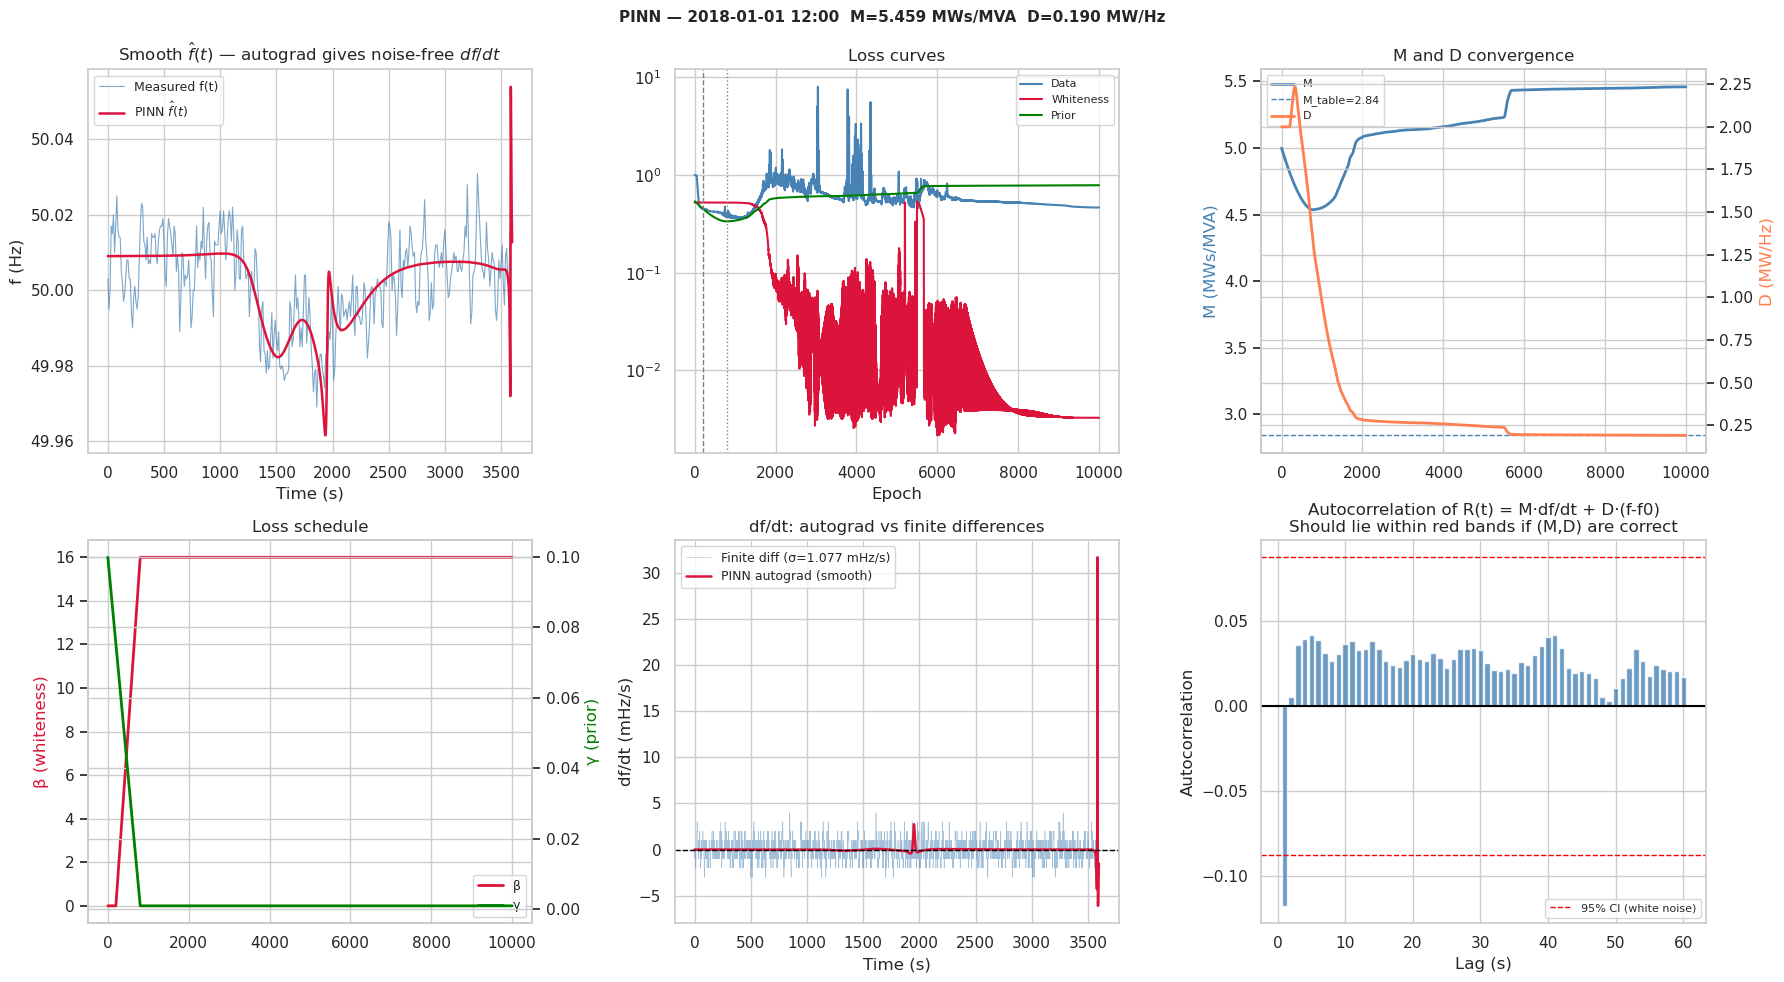

In [34]:
model.eval()
t_seconds = np.arange(len(window['f_raw_hz']))

with torch.no_grad():
    f_pred_hz = model(window['t_norm'].to(DEVICE)).cpu().squeeze().numpy()

t_dfdt = window['t_norm'].to(DEVICE).requires_grad_(True)
dfdt_pred = model.dfdt_hz(t_dfdt).detach().cpu().squeeze().numpy()
dfdt_raw  = np.diff(window['f_raw_hz'], prepend=window['f_raw_hz'][0])

# Residual at 500 collocation points
t_res   = torch.linspace(0,1,500).unsqueeze(1).to(DEVICE).requires_grad_(True)
idx_r   = torch.linspace(0, len(window['f_dev'])-1, 500).long()
fdev_r  = window['f_dev'][idx_r].to(DEVICE)
R_phys  = model.residual(t_res, fdev_r).detach().cpu().squeeze().numpy()

# Autocorrelation of R
R_t     = torch.from_numpy(R_phys)
ac_lags = list(range(1, 61))
ac_vals = [autocorr(R_t, lag).item() for lag in ac_lags]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# f(t) fit
axes[0,0].plot(t_seconds[::10], window['f_raw_hz'][::10],
               color='steelblue', lw=0.8, alpha=0.7, label='Measured f(t)')
axes[0,0].plot(t_seconds, f_pred_hz, color='crimson', lw=1.8,
               label='PINN $\\hat{f}(t)$')
axes[0,0].set_xlabel('Time (s)'); axes[0,0].set_ylabel('f (Hz)')
axes[0,0].set_title('Smooth $\\hat{f}(t)$ — autograd gives noise-free $df/dt$')
axes[0,0].legend(fontsize=9)

# Loss curves
axes[0,1].semilogy(log_df['epoch'], log_df['loss_data'],
                   color='steelblue', lw=1.5, label='Data')
axes[0,1].semilogy(log_df['epoch'], log_df['loss_white'].clip(1e-12),
                   color='crimson', lw=1.5, label='Whiteness')
axes[0,1].semilogy(log_df['epoch'], log_df['loss_prior'].clip(1e-12),
                   color='green', lw=1.5, label='Prior')
axes[0,1].axvline(WARMUP_DATA, color='gray', ls='--', lw=1)
axes[0,1].axvline(WARMUP_PHYS, color='gray', ls=':', lw=1)
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_title('Loss curves')
axes[0,1].legend(fontsize=8)

# M and D evolution
axD = axes[0,2].twinx()
axes[0,2].plot(log_df['epoch'], log_df['M'], color='steelblue', lw=2, label='M')
axes[0,2].axhline(M_table_mean, color='steelblue', ls='--', lw=1,
                  label=f'M_table={M_table_mean:.2f}')
axD.plot(log_df['epoch'], log_df['D'], color='coral', lw=2, label='D')
axes[0,2].set_ylabel('M (MWs/MVA)', color='steelblue')
axD.set_ylabel('D (MW/Hz)', color='coral')
axes[0,2].set_title('M and D convergence')
l1,lb1 = axes[0,2].get_legend_handles_labels()
l2,lb2 = axD.get_legend_handles_labels()
axes[0,2].legend(l1+l2, lb1+lb2, fontsize=8)

# Schedule
axg = axes[1,0].twinx()
axes[1,0].plot(log_df['epoch'], log_df['beta'], color='crimson', lw=2, label='β')
axg.plot(log_df['epoch'], log_df['gamma'], color='green', lw=2, label='γ')
axes[1,0].set_ylabel('β (whiteness)', color='crimson')
axg.set_ylabel('γ (prior)', color='green')
axes[1,0].set_title('Loss schedule')
l1,lb1 = axes[1,0].get_legend_handles_labels()
l2,lb2 = axg.get_legend_handles_labels()
axes[1,0].legend(l1+l2, lb1+lb2, fontsize=9)

# df/dt comparison
axes[1,1].plot(t_seconds, dfdt_raw*1000, color='steelblue', lw=0.4,
               alpha=0.5, label=f'Finite diff (σ={dfdt_raw.std()*1000:.3f} mHz/s)')
axes[1,1].plot(t_seconds, dfdt_pred*1000, color='crimson', lw=1.8,
               label='PINN autograd (smooth)')
axes[1,1].axhline(0, color='black', lw=1, ls='--')
axes[1,1].set_xlabel('Time (s)'); axes[1,1].set_ylabel('df/dt (mHz/s)')
axes[1,1].set_title('df/dt: autograd vs finite differences')
axes[1,1].legend(fontsize=9)

# Autocorrelation of R
axes[1,2].bar(ac_lags, ac_vals, color='steelblue', alpha=0.8)
axes[1,2].axhline(0, color='black', lw=1.5)
axes[1,2].axhline( 1.96/np.sqrt(500), color='red', lw=1, ls='--',
                   label='95% CI (white noise)')
axes[1,2].axhline(-1.96/np.sqrt(500), color='red', lw=1, ls='--')
axes[1,2].set_xlabel('Lag (s)'); axes[1,2].set_ylabel('Autocorrelation')
axes[1,2].set_title(
    'Autocorrelation of R(t) = M·df/dt + D·(f-f0)\n'
    'Should lie within red bands if (M,D) are correct'
)
axes[1,2].legend(fontsize=8)

plt.suptitle(
    f'PINN — {window["index"][0].strftime("%Y-%m-%d %H:%M")}  '
    f'M={model.M:.3f} MWs/MVA  D={model.D:.3f} MW/Hz',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(); plt.show()

## 7. Ensemble — uncertainty from member disagreement

In [35]:
def train_member(seed, window, epochs=EPOCHS, M_init=M_INIT, D_init=D_INIT):
    set_seed(seed)
    m = InertiaPINN(
        scalers=window['scalers'],
        hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS,
        t_scale=window['t_scale'],
        M_init=M_init, D_init=D_init,
    ).to(DEVICE)
    crit  = PINNLoss(
        alpha=ALPHA, beta_max=BETA_MAX,
        gamma_max=GAMMA_MAX, gamma_min=GAMMA_MIN,
        M_prior=M_PRIOR, M_std=M_STD,
        lags=AUTOCORR_LAGS,
        warmup_data=WARMUP_DATA, warmup_phys=WARMUP_PHYS,
    )
    opt   = torch.optim.Adam(m.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)

    t_n = window['t_norm'].to(DEVICE).requires_grad_(True)
    f_s = window['f_s'].to(DEVICE)
    t_c, fdev_c = make_colloc(window, N_COLLOC, DEVICE)

    for epoch in range(1, epochs+1):
        m.train()
        crit.schedule(epoch)
        f_s_pred = m._forward_scaled(t_n)
        R        = m.residual(t_c, fdev_c)
        loss, _  = crit(f_s_pred, f_s, R,
                        nn.functional.softplus(m._M_raw))
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step(); sched.step()
    return m


print(f'Training {N_MEMBERS}-member ensemble...')
members = []
for mid in range(N_MEMBERS):
    m = train_member(GLOBAL_SEED + mid*100, window)
    members.append(m)
    print(f'  Member {mid+1}: M={m.M:.4f} MWs/MVA  D={m.D:.4f} MW/Hz')

M_vals = [m.M for m in members]
D_vals = [m.D for m in members]
print(f'\nEnsemble M : {np.mean(M_vals):.4f} ± {np.std(M_vals):.4f} MWs/MVA')
print(f'Ensemble D : {np.mean(D_vals):.4f} ± {np.std(D_vals):.4f} MW/Hz')
print(f'Table M    : {M_table_mean:.4f} MWs/MVA')

Training 5-member ensemble...
  Member 1: M=5.4586 MWs/MVA  D=0.1899 MW/Hz
  Member 2: M=5.3996 MWs/MVA  D=0.2110 MW/Hz
  Member 3: M=5.4335 MWs/MVA  D=0.2225 MW/Hz
  Member 4: M=5.4310 MWs/MVA  D=0.1806 MW/Hz
  Member 5: M=5.4011 MWs/MVA  D=0.2157 MW/Hz

Ensemble M : 5.4248 ± 0.0221 MWs/MVA
Ensemble D : 0.2039 ± 0.0160 MW/Hz
Table M    : 2.8431 MWs/MVA


## 8. Sliding window — M(t) and D(t) over one day

In [36]:
starts = list(range(0, 24*3600 - WINDOW_S, STEP_S))
print(f'Training {len(starts)} windows...')

results  = []
M_prev   = M_INIT   # warm-start first window at config init
D_prev   = D_INIT

for wi, start in enumerate(starts):
    if start + WINDOW_S > len(df_freq): break
    win = prepare_window(df_freq, df_15, start, WINDOW_S)

    # Warm-start from previous window's result
    # This propagates the solution forward in time rather than
    # restarting cold at M_INIT=5.0 every window
    m = train_member(GLOBAL_SEED, win, epochs=2000,
                     M_init=M_prev, D_init=D_prev)

    M_prev = m.M
    D_prev = m.D
    t_mid  = win['index'][len(win['index'])//2]
    results.append(dict(timestamp=t_mid, M=m.M, D=m.D))

    if wi % 4 == 0 or wi == len(starts)-1:
        print(f'  [{wi+1:2d}/{len(starts)}] {t_mid.strftime("%H:%M")}  '
              f'M={m.M:.3f} MWs/MVA  D={m.D:.3f} MW/Hz')

df_res = pd.DataFrame(results).set_index('timestamp')
print(f'\nM range: [{df_res["M"].min():.3f}, {df_res["M"].max():.3f}] MWs/MVA')
print(f'D range: [{df_res["D"].min():.3f}, {df_res["D"].max():.3f}] MW/Hz')

Training 46 windows...
  [ 1/46] 00:30  M=4.847 MWs/MVA  D=0.978 MW/Hz
  [ 5/46] 02:30  M=4.535 MWs/MVA  D=0.107 MW/Hz
  [ 9/46] 04:30  M=4.242 MWs/MVA  D=0.016 MW/Hz
  [13/46] 06:30  M=3.840 MWs/MVA  D=0.010 MW/Hz
  [17/46] 08:30  M=3.466 MWs/MVA  D=0.003 MW/Hz
  [21/46] 10:30  M=3.114 MWs/MVA  D=0.001 MW/Hz
  [25/46] 12:30  M=2.699 MWs/MVA  D=0.002 MW/Hz
  [29/46] 14:30  M=2.830 MWs/MVA  D=0.002 MW/Hz
  [33/46] 16:30  M=3.217 MWs/MVA  D=0.001 MW/Hz
  [37/46] 18:30  M=2.503 MWs/MVA  D=0.001 MW/Hz
  [41/46] 20:30  M=3.071 MWs/MVA  D=0.002 MW/Hz
  [45/46] 22:30  M=2.653 MWs/MVA  D=0.002 MW/Hz
  [46/46] 23:00  M=2.583 MWs/MVA  D=0.002 MW/Hz

M range: [2.238, 4.847] MWs/MVA
D range: [0.001, 0.978] MW/Hz


## 9. Headline results

PINN M(t) vs table. PINN higher because it captures load-side inertia.
D(t) is entirely new — table method has no estimate for damping at all.

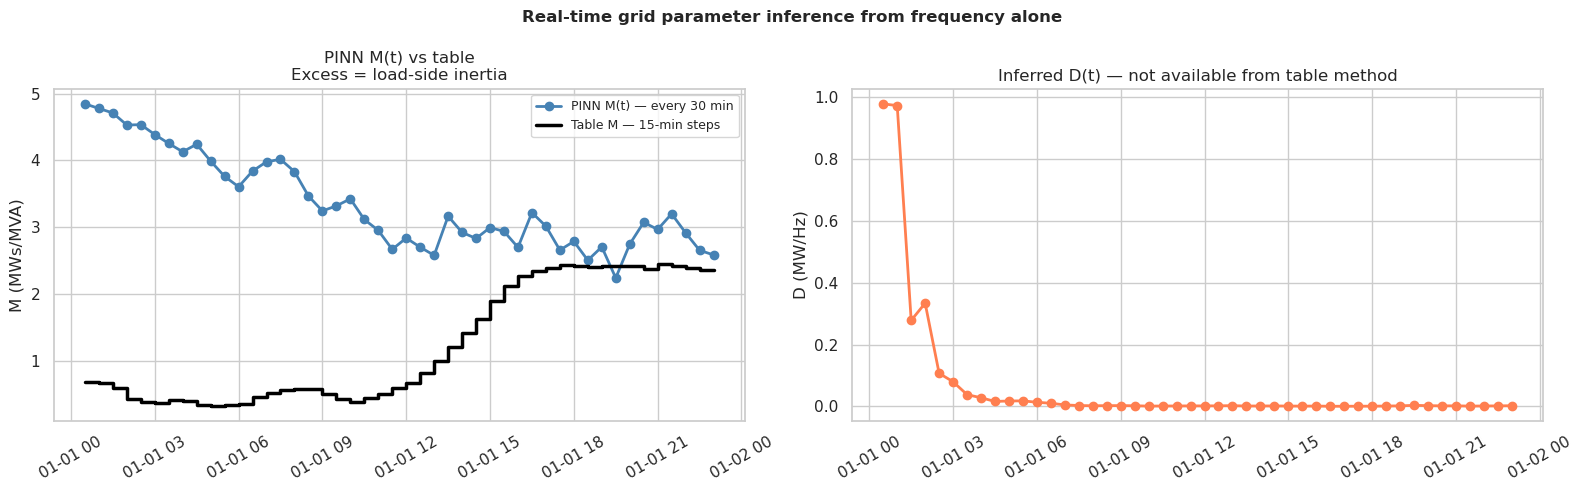


RESULTS

PINN M : 3.3588 ± 0.7080 MWs/MVA
Table M: 1.2462 MWs/MVA
Excess : +2.1126 MWs/MVA — load-side inertia not in table
PINN D : 0.0642 ± 0.2067 MW/Hz

M and D identified from frequency statistics alone.
No generation dispatch data required.
Smooth df/dt from autograd — not finite differences on noisy data.


In [37]:
H_trad_day = H_trad.reindex(
    df_res.index, method='nearest', tolerance=pd.Timedelta('15min')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df_res.index, df_res['M'], 'o-',
             color='steelblue', lw=2, ms=6,
             label=f'PINN M(t) — every {STEP_S//60} min')
if H_trad_day.notna().any():
    axes[0].step(H_trad_day.dropna().index, H_trad_day.dropna().values,
                 where='post', color='black', lw=2.5,
                 label='Table M — 15-min steps')
axes[0].set_ylabel('M (MWs/MVA)')
axes[0].set_title('PINN M(t) vs table\nExcess = load-side inertia')
axes[0].legend(fontsize=9); axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(df_res.index, df_res['D'], 'o-',
             color='coral', lw=2, ms=6)
axes[1].set_ylabel('D (MW/Hz)')
axes[1].set_title('Inferred D(t) — not available from table method')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Real-time grid parameter inference from frequency alone',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n' + '='*60)
print('RESULTS')
print('='*60)
print(f'\nPINN M : {df_res["M"].mean():.4f} ± {df_res["M"].std():.4f} MWs/MVA')
if H_trad_day.notna().any():
    delta = df_res['M'].mean() - H_trad_day.mean()
    print(f'Table M: {H_trad_day.mean():.4f} MWs/MVA')
    print(f'Excess : +{delta:.4f} MWs/MVA — load-side inertia not in table')
print(f'PINN D : {df_res["D"].mean():.4f} ± {df_res["D"].std():.4f} MW/Hz')
print(f'\nM and D identified from frequency statistics alone.')
print(f'No generation dispatch data required.')
print(f'Smooth df/dt from autograd — not finite differences on noisy data.')

In [39]:
# Save ensemble
for mid, m in enumerate(members):
    torch.save(m.state_dict(), CKPT_DIR / f'member_{mid}.pt')
print(f'Saved {len(members)} members to {CKPT_DIR}')

Saved 5 members to ../checkpoints/pinn
